# Basic utils for Investing based on Indicators

## Imports

In [2]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random


# Attribution d'une graine.
random.seed(1)

torch.manual_seed(1)

%reload_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data reading and processing

In [38]:
pair = 'SOLUSDT'
timeframe = '1m'
type_data = 'Futures'

# Importation des données


data = pd.read_csv(f'../data/binance/{pair}_{timeframe}_{type_data}.csv', parse_dates=[0], index_col=0)
data

,Open,High,Low,Close,Volume,Qav,Trades,Taker_base_vol,Taker_quote_vol
Date,,,,,,,,,
2020-09-14 09:00:00,3.2002,4.9100,3.2002,3.2745,11567,3.947478e+04,80,3948,1.434407e+04
2020-09-14 09:01:00,3.2731,3.3422,3.2709,3.3192,11766,3.893731e+04,134,4521,1.497126e+04
2020-09-14 09:02:00,3.3193,3.3500,3.3132,3.3460,8180,2.731099e+04,130,4733,1.582697e+04
2020-09-14 09:03:00,3.3318,3.3521,3.3150,3.3151,3937,1.312853e+04,73,361,1.208650e+03
2020-09-14 09:04:00,3.3151,3.3160,3.2725,3.3045,7248,2.384239e+04,223,1704,5.601760e+03
...,...,...,...,...,...,...,...,...,...
2024-09-04 12:18:00,129.1950,129.2270,128.8030,129.0140,46529,6.001289e+06,3770,12890,1.662648e+06
2024-09-04 12:19:00,129.0140,129.0240,128.8390,128.9530,14937,1.925856e+06,1713,5248,6.766300e+05
2024-09-04 12:20:00,128.9530,129.2390,128.9460,129.1980,24019,3.100629e+06,2838,13556,1.750026e+06


0.0003461490365280987


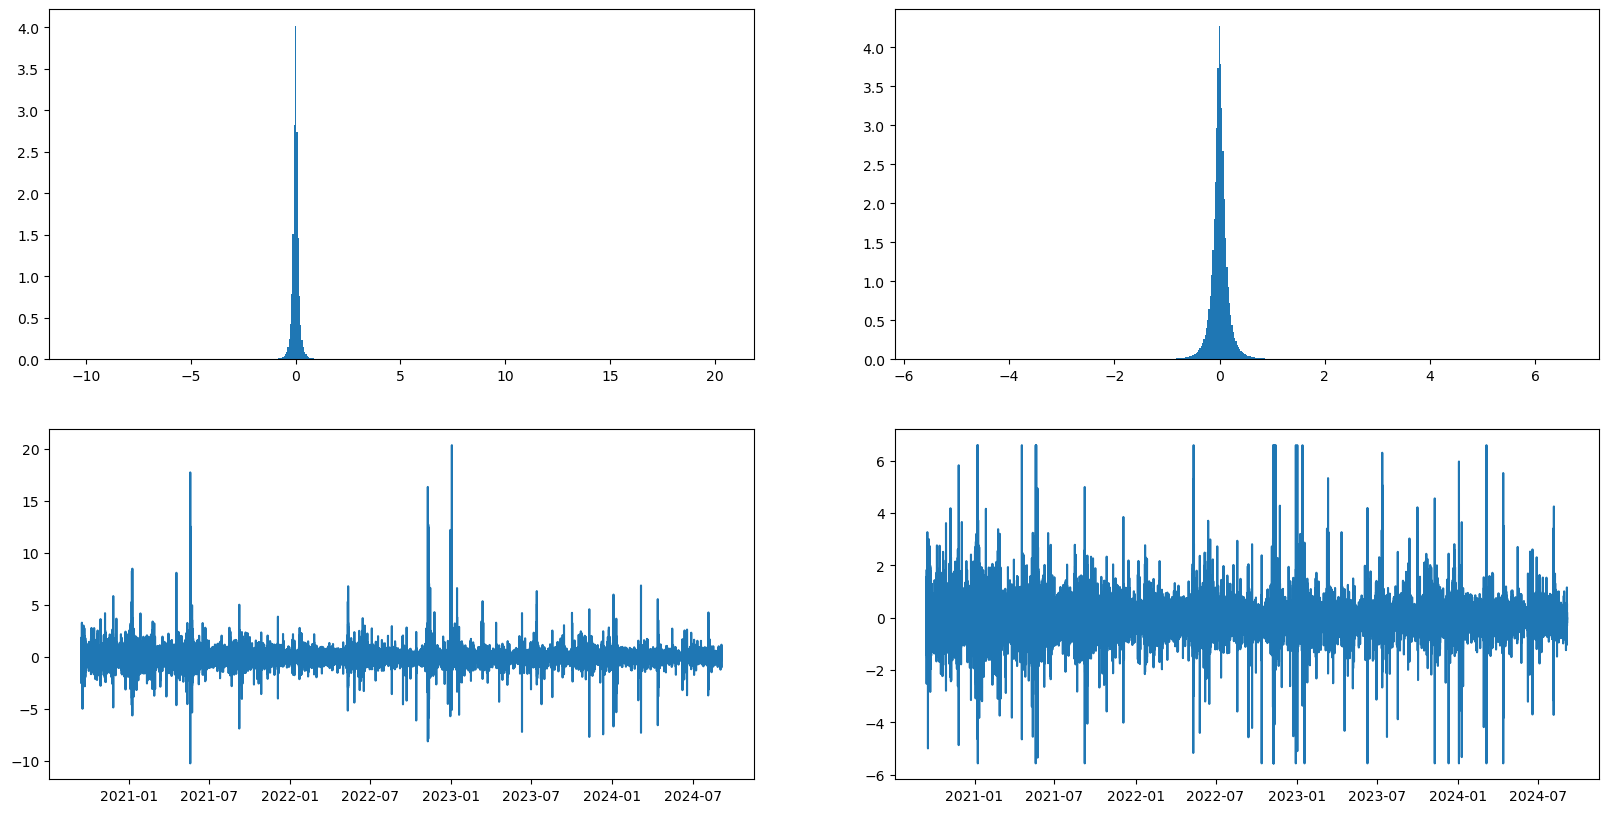

In [40]:
data.loc[:, '%R'] = data['Close'].pct_change()*100

df = data[['%R']].copy()

quatiles_threshold = 0.00001

plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)    
plt.hist(df['%R'] , bins=500, density=True)

plt.subplot(2, 2, 3)
plt.plot(df['%R'])

df['%R'] = df['%R'].clip(lower=df['%R'].quantile(quatiles_threshold), upper=df['%R'].quantile(1-quatiles_threshold))

print(df['%R'].mean())

# df['%R'] = df['%R'] - df['%R'].mean()

plt.subplot(2, 2, 2)
plt.hist(df['%R'], bins=500, density=True)

plt.subplot(2, 2, 4)
plt.plot(df['%R'])

plt.show()

In [41]:
# import ta

df.dropna(inplace=True)

In [42]:
df.describe()

,%R
count,2.089642e+06
mean,3.461490e-04
std,1.925372e-01
min,-5.565595e+00
25%,-7.250637e-02
50%,0.000000e+00
75%,7.212776e-02
max,6.600043e+00


In [43]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

train_data, test_data = df[:int(len(data)*0.8)], df[int(len(data)*0.8):]

train_data = train_data.to_numpy()

test_data = test_data.to_numpy()

start_index = 0

train_target = train_data[:, :1]

test_target = test_data[:, :1]

for k in range(0, 2):
    train_target = train_target - train_target.mean()
    test_target = test_target - test_target.mean()
    
    print(f'k = {k}: train_target mean = {train_target.mean()}, test_target mean = {test_target.mean()}')

scaler = StandardScaler()


train_data = scaler.fit_transform(train_data[:, start_index:]) 
test_data = scaler.transform(test_data[:, start_index:])

k = 0: train_target mean = -1.1311335883659327e-18, test_target mean = 5.467063668092523e-18
k = 1: train_target mean = -9.866205136662926e-19, test_target mean = -8.468901347851781e-19


In [44]:
class ExpInvestLoss(nn.Module):
    def __init__(self, alpha=0.1):
        super(ExpInvestLoss, self).__init__()
        self.alpha = alpha

    def forward(self, y_pred, y_true):
        
        return torch.exp(-y_true*y_pred*self.alpha).mean()
    
class InvestLoss(nn.Module):
    def __init__(self, alpha=0):
        super(InvestLoss, self).__init__()
        self.alpha = alpha
    def forward(self, y_pred, y_true):
        
        r = y_true*y_pred
        
        return -r.mean()
    
class DiffInvestLoss(nn.Module):
    def __init__(self, fee=0.04):
        super(DiffInvestLoss, self).__init__()
        self.fee = fee
    def forward(self, inv, diff_inv, returns):
        
        if not self.fee == 0:
            return -((inv*returns).mean() - self.fee * diff_inv.abs().mean())

        else:
            return -(inv*returns).mean()

In [45]:
src = torch.tensor(train_data[:-1], dtype=torch.float32).to(device)
tgt = torch.tensor(train_target[1:], dtype=torch.float32).to(device)

class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        
        self.linear = nn.Linear(1, 1)
        
        self.tanh = nn.Tanh()

    def forward(self, x):
        return self.tanh(self.linear(x))
    
    
model = Model().to(device)

criterion = DiffInvestLoss(fee=0.04)

optimizer = torch.optim.Adam(model.parameters(), lr=1e0, amsgrad=True, weight_decay=1e-7)

losses = []

a = []
b = []

In [10]:
print(model.linear.weight.item(), model.linear.bias.item())

for epoch in tqdm(range(1000)):
    model.train()
    optimizer.zero_grad()
    
    a.append(model.linear.weight.item())
    b.append(model.linear.bias.item())
    
    inv = model(src).squeeze()
    diff_inv = inv.diff()
    
    loss = criterion(inv, diff_inv, tgt.squeeze())
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, loss {loss.item():.3E}')

0.5152631998062134 -0.44137823581695557


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0, loss 1.328E-02
Epoch 100, loss -1.055E-03
Epoch 200, loss -1.066E-03
Epoch 300, loss -1.074E-03
Epoch 400, loss -1.081E-03
Epoch 500, loss -1.086E-03
Epoch 600, loss -1.090E-03
Epoch 700, loss -1.093E-03
Epoch 800, loss -1.096E-03
Epoch 900, loss -1.099E-03


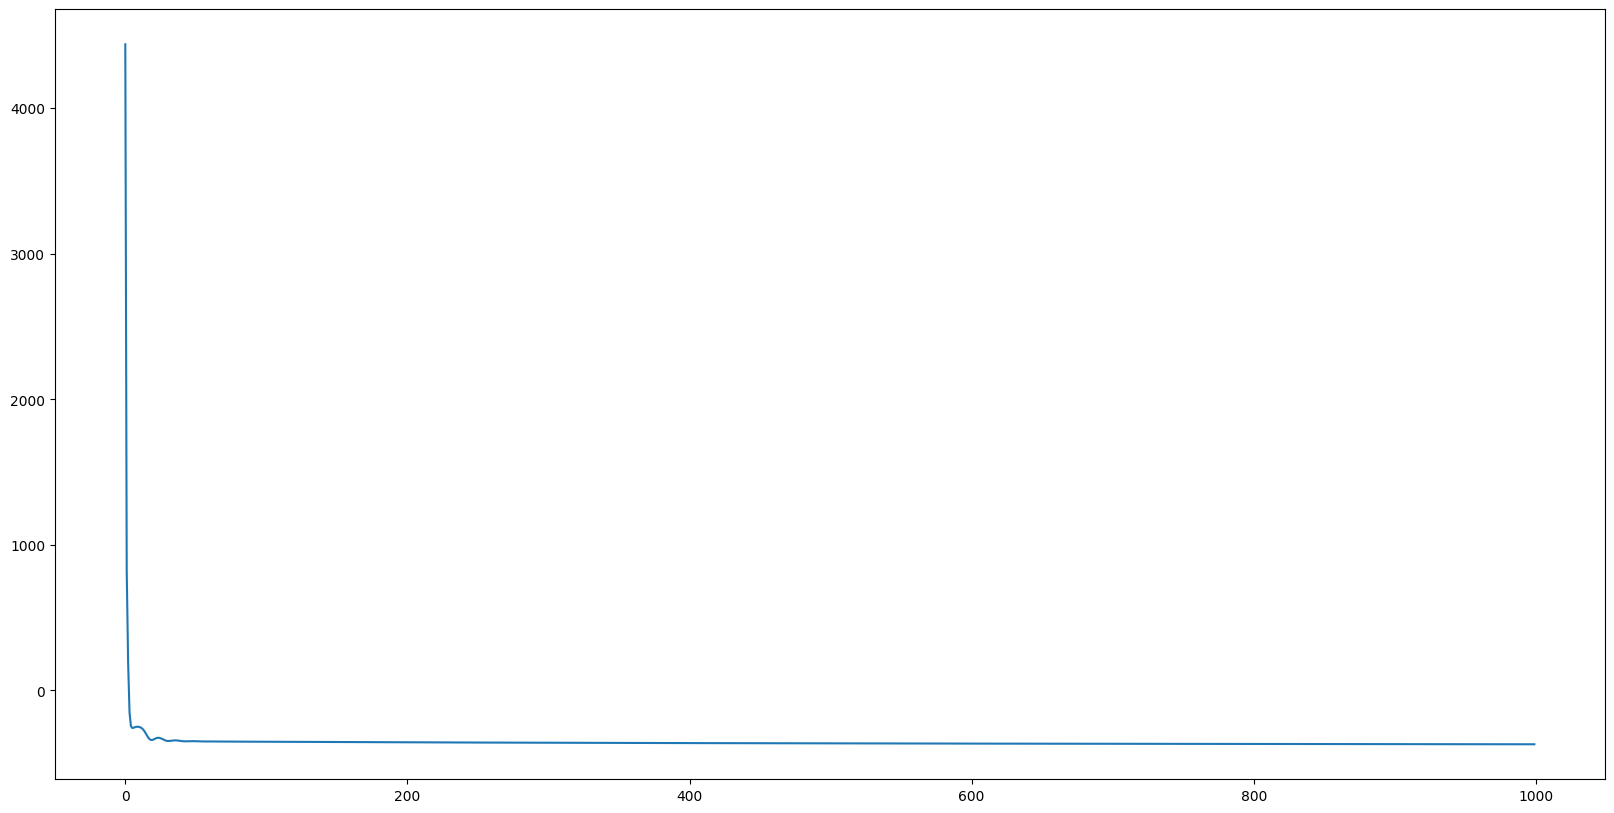

In [10]:
plt.figure(figsize=(20, 10))
plt.plot(losses)

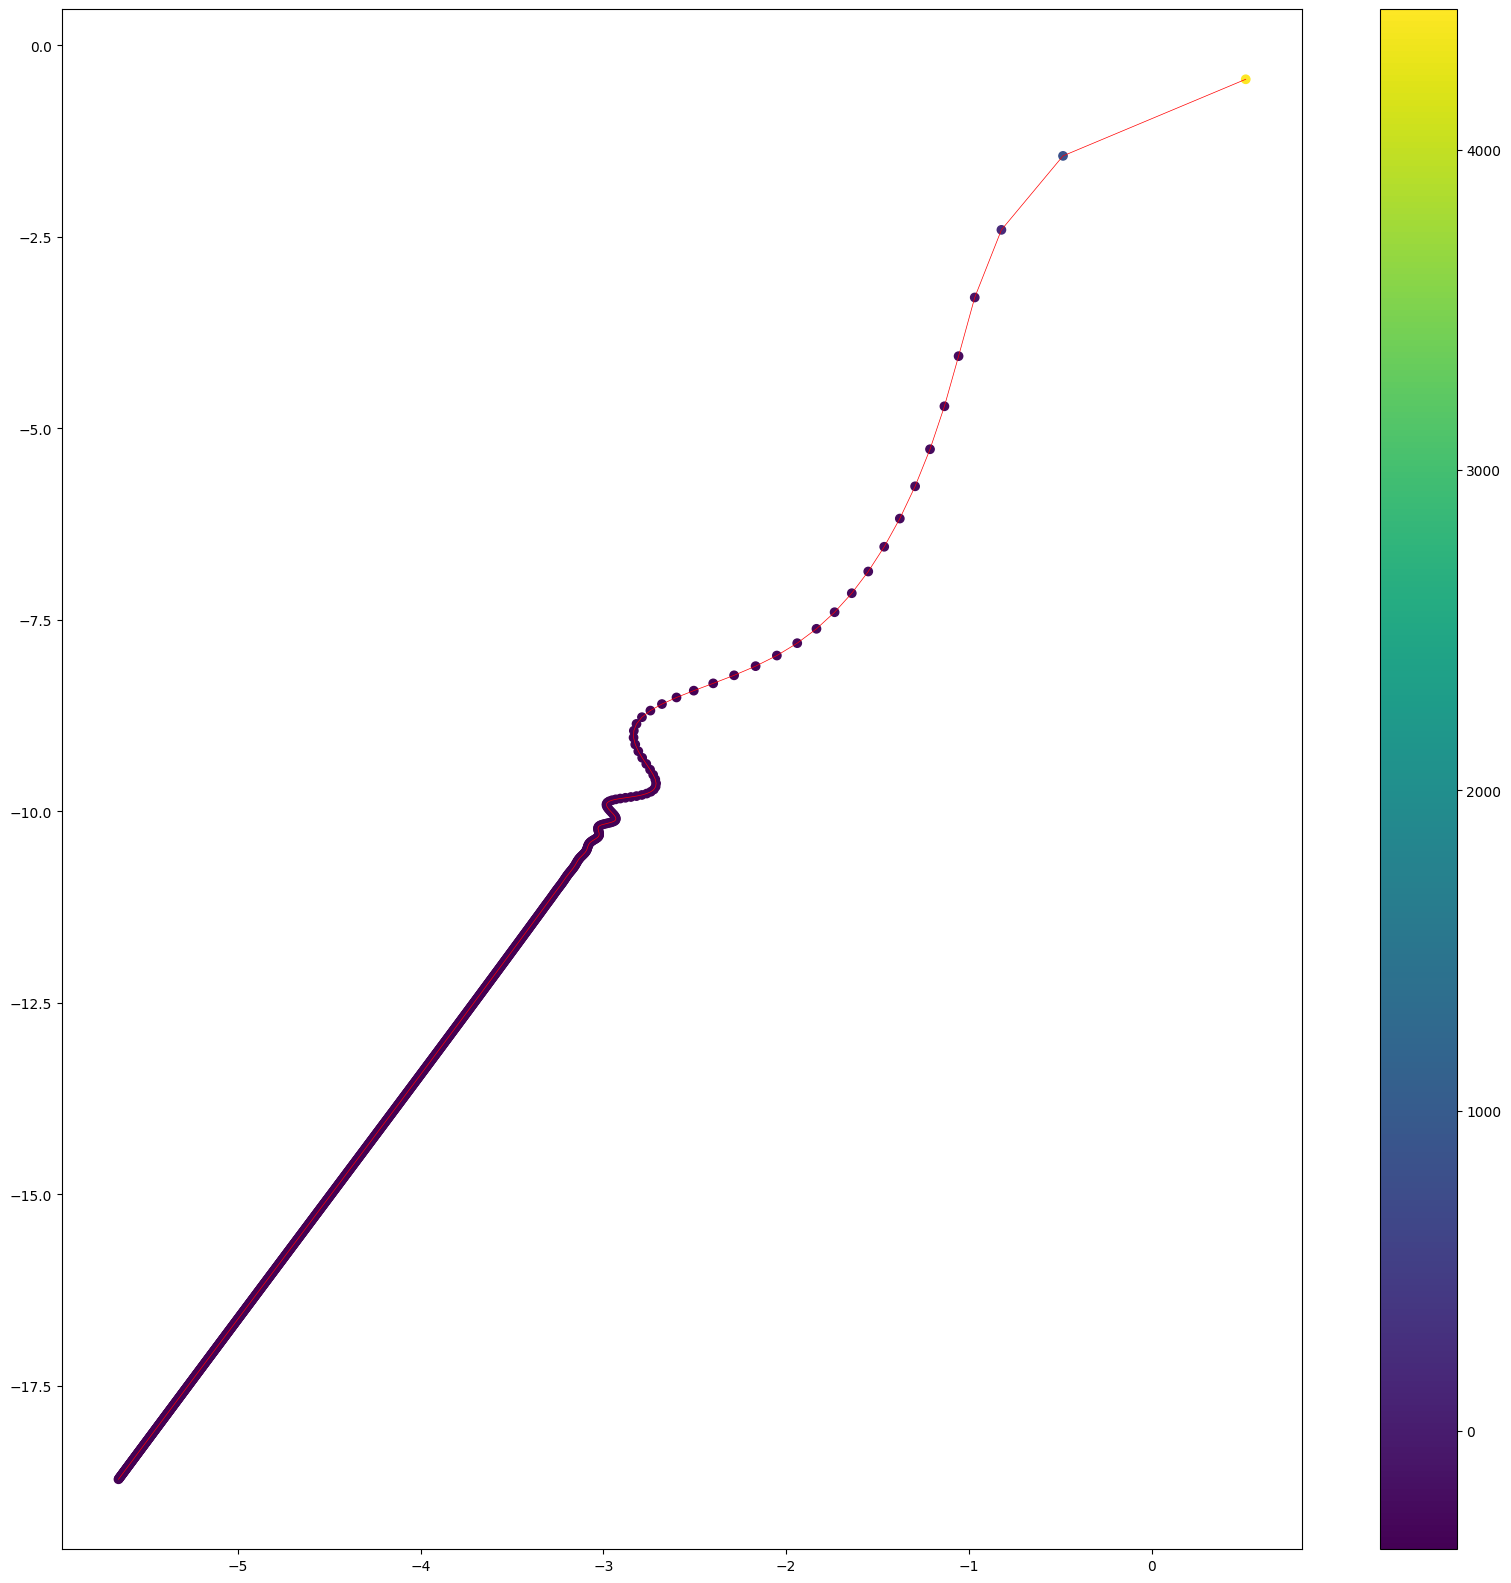

In [11]:
plt.figure(figsize=(20, 20))
plt.scatter(a, b, c=losses, cmap='viridis')
plt.colorbar()
plt.plot(a, b, c='red', lw=0.5)

In [46]:
import itertools

def ev(a,b, data):
    return torch.tanh(a*data + b)

a_grid = np.linspace(-10, 0, 101)
b_grid = np.linspace(-25, 25, 101)



def grid(grid_a, grid_b, data, tgt):
    
    score = []
    
    for a, b in itertools.product(grid_a, grid_b):
        inv = ev(a, b, data).squeeze()
        diff_inv = inv.diff()
        loss = criterion(inv, diff_inv, tgt.squeeze())+1e-7*(a**2 + b**2)
        score.append([a, b, -loss.item()])
    
    return np.array(score)

score = grid(a_grid, b_grid, src, tgt)

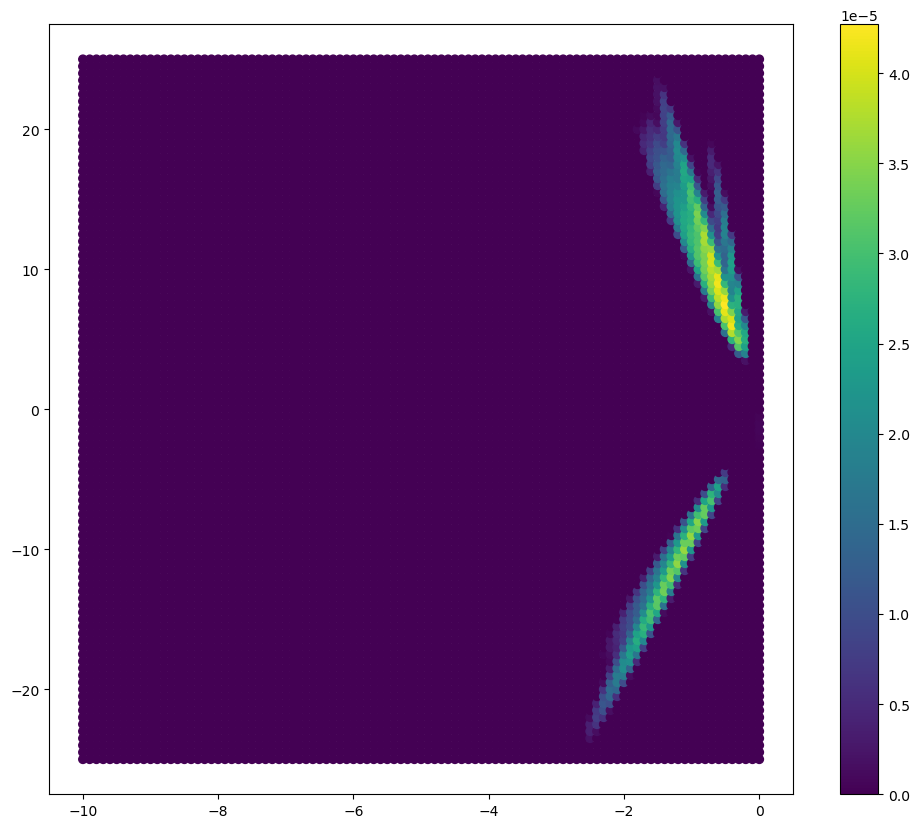

In [47]:
plt.figure(figsize=(12, 10))
plt.scatter(score[:, 0], score[:, 1], c=score[:, 2].clip(0), cmap='viridis')
plt.colorbar()

plt.plot(a, b, c='red', lw=0.5, )

-0.5 7.5


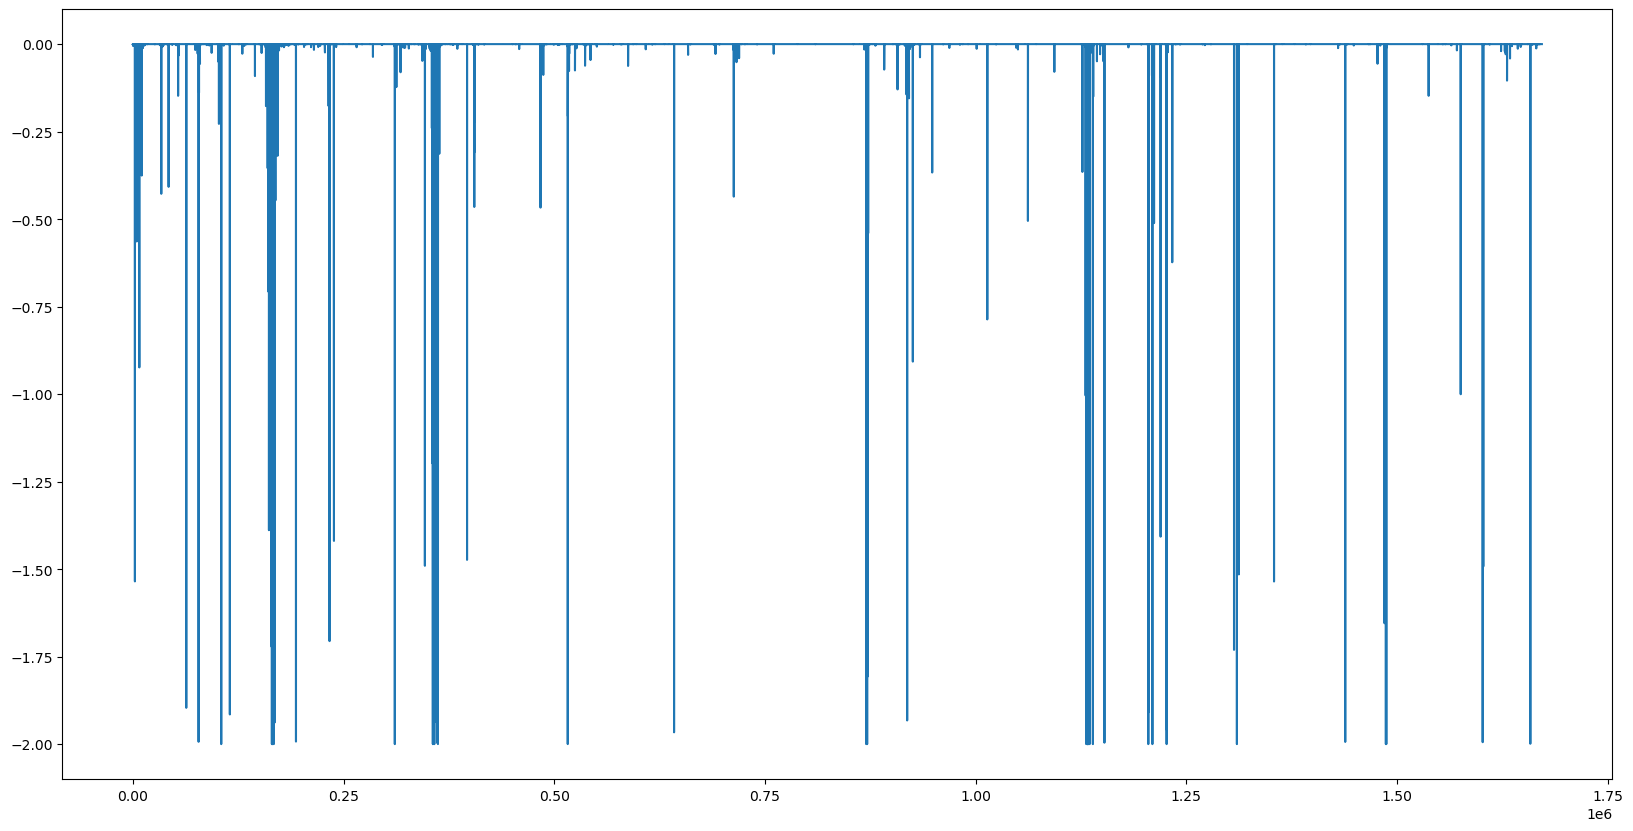

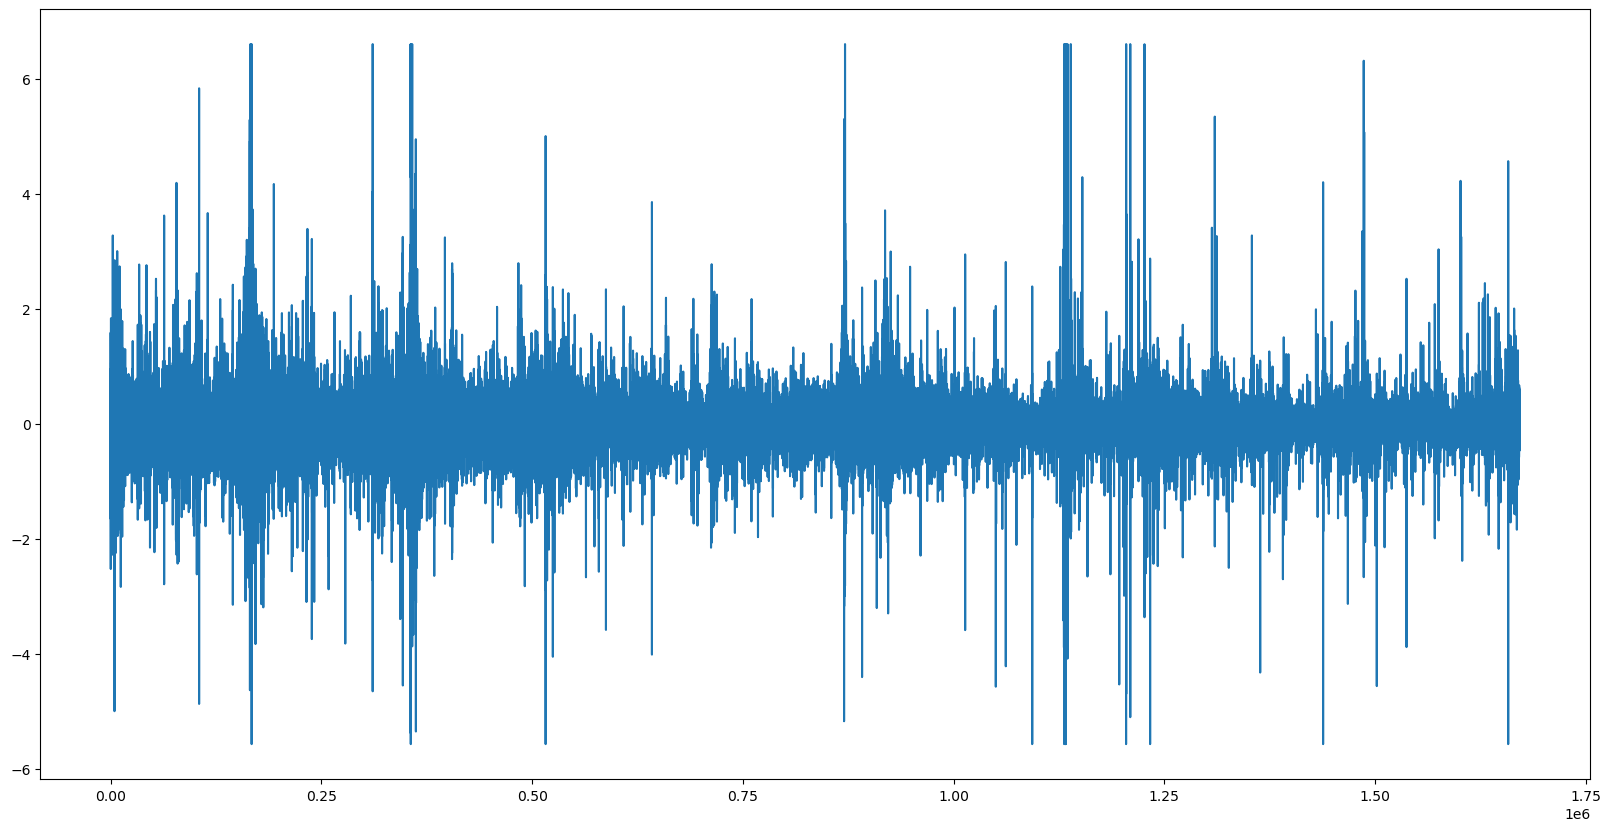

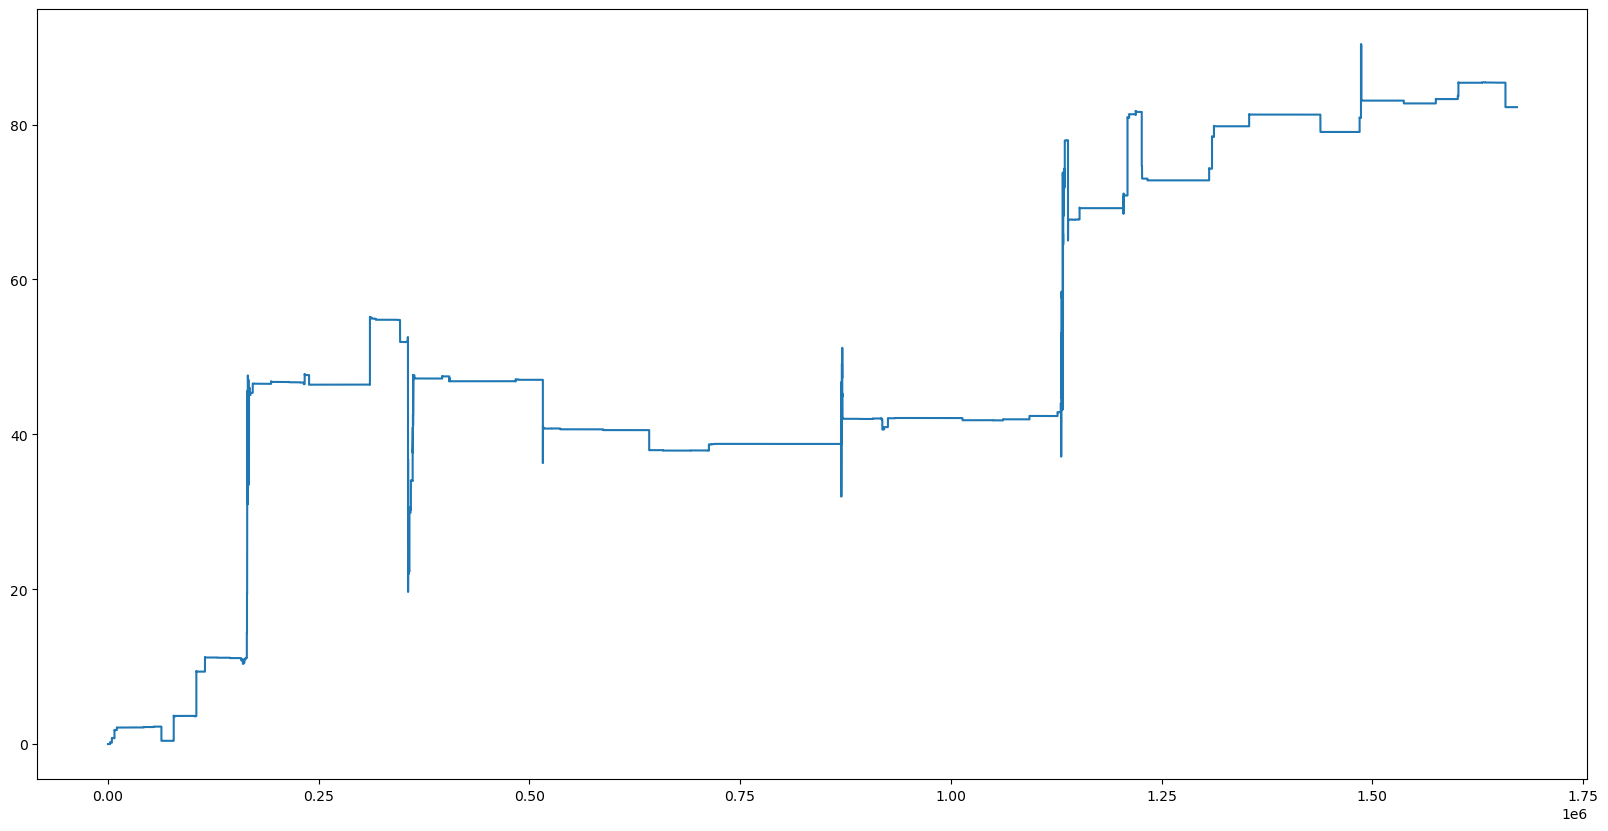

In [49]:
a_max, b_max = score[score[:, 2].argmax(), :2]

# a_max, b_max = -2, -80

print(a_max, b_max)

inv = ev(a_max, b_max, src).squeeze()-1
diff_inv = torch.cat([torch.tensor([0.0], device=device), inv]).diff()

returns = tgt.squeeze()*inv - 0.04*diff_inv.abs()


plt.figure(figsize=(20, 10))

plt.plot(inv.cpu().detach().numpy())

plt.figure(figsize=(20, 10))

plt.plot(tgt.cpu().detach().numpy())

plt.figure(figsize=(20, 10))
plt.plot(np.cumsum(returns.cpu().detach().numpy()))
